# Stability: number of FISTA iterations (10 degree mosaicity sample)

The reconstruction of `texture_tomography/domains_mosaicity_10p0deg/textomo_adaptive.ipynb`
(adaptive basis, unregularised nonnegative FISTA-Huber, field-of-view support) for a range of
iteration counts, everything else fixed. FISTA is deterministic, so the reconstruction after
n iterations is the n-th iterate of a longer run: the sweep shows how the solution evolves.

Evaluation: 1. IPF-Z maps, 2. misorientation maps to the ground truth, 3. mean / median
misorientation, 4. grain and subgrain boundaries with statistics, 5. the differences between the
reconstructions, 6. data versus prediction. Reconstructions, figures and tables go to `processed/stability/<sample>/iterations/`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from simtools import paths, stability


def panel_axes(n, ncols=5, size=4.0):
    """A grid of image axes for n panels, without ticks; unused axes are hidden."""
    nrows = -(-n // ncols)
    fig, ax = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows), squeeze=False)
    for a in ax.ravel():
        a.axis("off")
    return fig, ax.ravel()


def heatmap(ax, df, title, fmt="{:.2f}"):
    im = ax.imshow(df.values, cmap="viridis")
    ax.set_xticks(range(len(df.columns)), df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(df.index)), df.index)
    for i in range(len(df.index)):
        for j in range(len(df.columns)):
            v = df.values[i, j]
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                    color="white" if v < 0.5 * np.nanmax(df.values) else "black")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

## Parameters

In [2]:
SAMPLE = "domains_mosaicity_10p0deg"
NITERS = [25, 50, 100, 200, 500, 1000, 2000, 5000]   # swept
SIGMA_DEG = 0.4             # kernel width (as in textomo_adaptive.ipynb)
HUBER_DELTA = 100.0         # as in textomo_adaptive.ipynb
RERUN = False               # False: reuse reconstructions already in OUT

UPSAMPLE = 4                # display grid: UPSAMPLE x 99 pixels per side (as in the figure notebooks)
TOP_K = 24                  # orientations per voxel entering the weighted medoid
MISORI_VMAX = 40.0          # deg, top of the misorientation colour scale (log scale)
GB_THRESHOLD = 4.0          # deg, KAM at or above this: grain boundary
SUBGRAIN_THRESHOLD = 0.5    # deg, KAM at or above this: subgrain boundary
OMEGA_INDEX = 90            # data vs prediction: rotation step (of 360, 0.5 deg each)
TRANSLATION_INDEX = 51      # data vs prediction: translation of the single frame (of 103; 51 = centre)
RING = None                 # ring of the eta profiles; None: the strongest ring of the frame
ZOOM_ETA = 15.0             # deg, half width of the zoom on the strongest peak of the profiles
IMAGE_GAMMA = 0.5           # colour scale of the ring x eta images: intensity ** IMAGE_GAMMA (weak, broad peaks visible)

OUT = os.path.join(paths.PROCESS, "stability", SAMPLE, "iterations")
os.makedirs(OUT, exist_ok=True)

values = np.array(NITERS)
labels = [f"{n} it" for n in NITERS]
files = {label: os.path.join(OUT, f"reconstruction_niter{n}.h5") for label, n in zip(labels, NITERS)}
PARAM_LABEL, PARAM_SCALE = "FISTA iterations", "log"

## Reconstructions
One operator (sigma is fixed); every iteration count is a run from zero. The objective of the
longest run shows the convergence; the relative weighted residual is ||w (A x - y)|| / ||w y||.

In [3]:
todo = [n for n, f in zip(NITERS, files.values()) if RERUN or not os.path.exists(f)]
if todo:
    problem = stability.load_problem(SAMPLE)
    rec = stability.Reconstructor(problem, SIGMA_DEG)
    print(f"K = {rec.K}, sigma = {SIGMA_DEG} deg, L = {rec.L:.4e}, PF matrix {rec.op.pf_mode}")
    for n in todo:
        coeffs, objective, residual, seconds = rec.run(n, HUBER_DELTA)
        stability.save_reconstruction(os.path.join(OUT, f"reconstruction_niter{n}.h5"), coeffs, rec.grid_mats,
                                      objective, sample=SAMPLE, sigma_deg=SIGMA_DEG, niter=n,
                                      huber_delta=HUBER_DELTA, residual=residual, fista_time_s=seconds)
        print(f"{n:5d} iterations: relative weighted residual {residual:.5f}, {seconds:.0f} s")
    rec.free()
    del rec, problem, coeffs

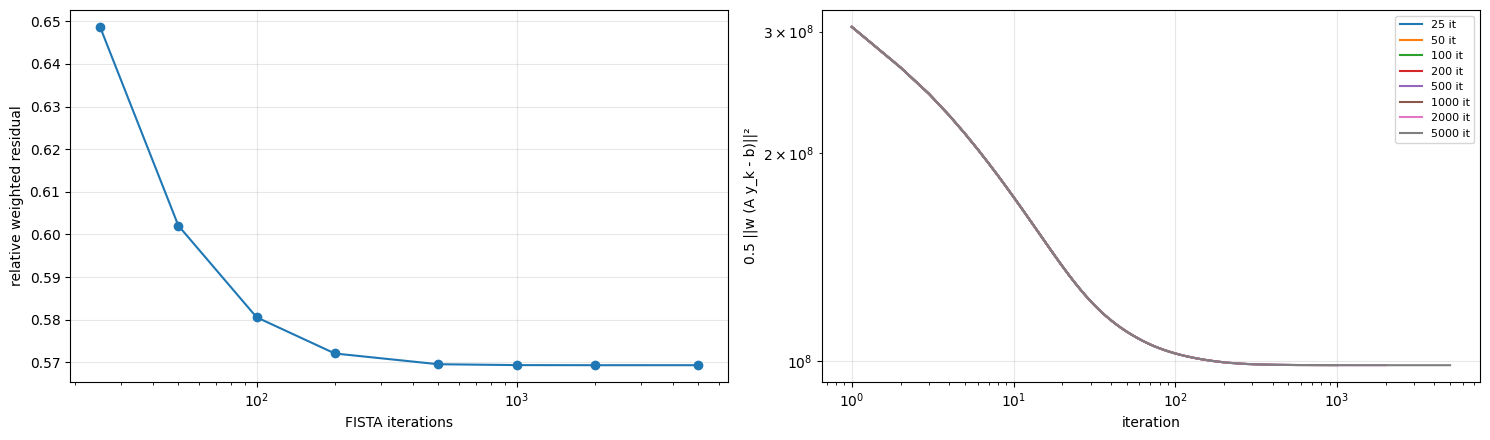

,sigma (deg),iterations,relative weighted residual,FISTA time (s)
run,,,,
25 it,0.4,25,0.64868,2.30346
50 it,0.4,50,0.60209,4.45764
100 it,0.4,100,0.58059,8.85059
200 it,0.4,200,0.57209,17.42409
500 it,0.4,500,0.56957,43.66516
1000 it,0.4,1000,0.56937,87.96084
2000 it,0.4,2000,0.56934,176.88550
5000 it,0.4,5000,0.56934,440.48185


In [4]:
runs, objectives = [], {}
for label, h5 in files.items():
    attrs, objectives[label] = stability.read_attrs(h5)
    runs.append({"run": label, "sigma (deg)": attrs["sigma_deg"], "iterations": attrs["niter"],
                 "relative weighted residual": attrs["residual"], "FISTA time (s)": attrs["fista_time_s"]})
runs = pd.DataFrame(runs).set_index("run")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].plot(values, runs["relative weighted residual"].values, "o-")
ax[0].set_xlabel(PARAM_LABEL)
ax[0].set_xscale(PARAM_SCALE)
ax[0].set_ylabel("relative weighted residual")
for label, obj in objectives.items():
    ax[1].plot(np.arange(1, len(obj) + 1), obj, label=label)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("0.5 ||w (A y_k - b)||²")
ax[1].legend(fontsize=8)
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "convergence.png"), dpi=100, bbox_inches="tight")
plt.show()
runs.round(5)

## Orientation maps
Per voxel, the weighted medoid of the `TOP_K` largest coefficients, upsampled `UPSAMPLE` x onto the
display grid of the ground truth (as in `visualization/<sample>/figure_panels.ipynb`). The medoids
are cached in `OUT` and recomputed when a reconstruction file changes.

In [5]:
grid = stability.display_grid(SAMPLE, UPSAMPLE)
maps = {}
for label, h5 in files.items():
    print(label)
    maps[label] = stability.medoid_map(h5, grid, os.path.join(OUT, f"medoid_{Path(h5).stem}.npz"), top_k=TOP_K)

25 it
  medoid from cache medoid_reconstruction_niter25.npz
50 it
  medoid from cache medoid_reconstruction_niter50.npz
100 it
  medoid from cache medoid_reconstruction_niter100.npz
200 it
  medoid from cache medoid_reconstruction_niter200.npz
500 it
  medoid from cache medoid_reconstruction_niter500.npz
1000 it
  medoid from cache medoid_reconstruction_niter1000.npz
2000 it
  medoid from cache medoid_reconstruction_niter2000.npz
5000 it
  medoid from cache medoid_reconstruction_niter5000.npz


## 1. IPF-Z maps

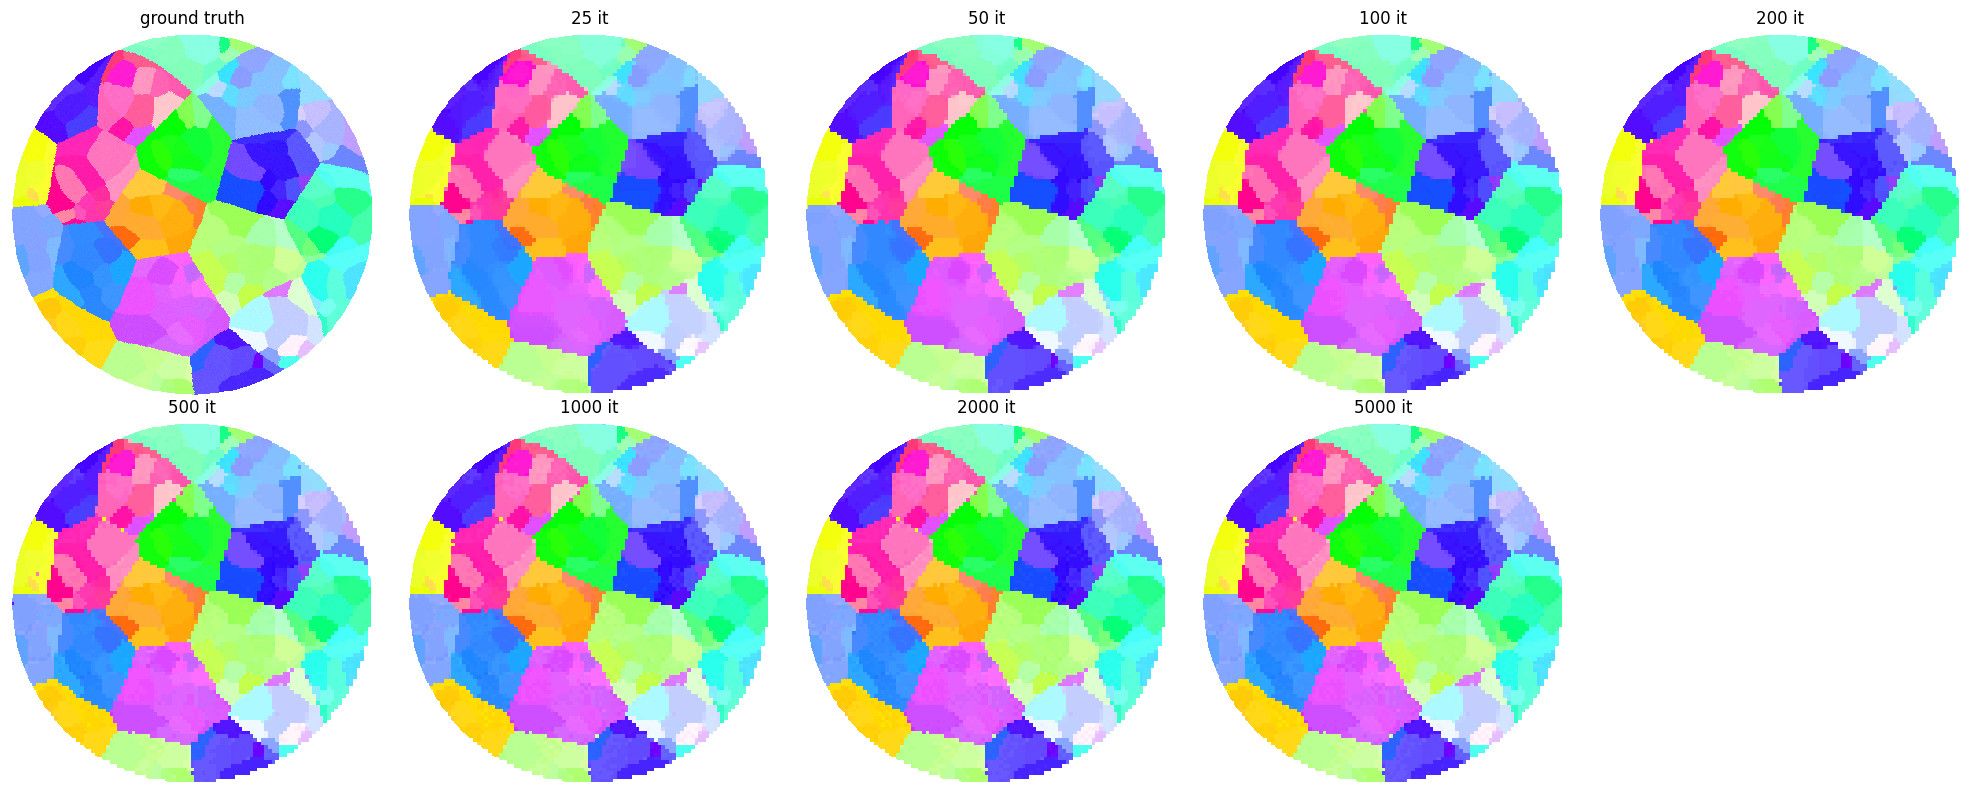

In [6]:
fig, ax = panel_axes(len(maps) + 1)
ax[0].imshow(stability.ipf_image(grid["gt"], grid["gt_valid"]), interpolation="nearest")
ax[0].set_title("ground truth")
for a, (label, (ori, valid)) in zip(ax[1:], maps.items()):
    a.imshow(stability.ipf_image(ori, valid), interpolation="nearest")
    a.set_title(label)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "ipf_z.png"), dpi=100, bbox_inches="tight")
plt.show()

## 2.-3. Misorientation to the ground truth
Maps on a log colour scale up to `MISORI_VMAX`, and the mean / median / 90th percentile over the
sample.

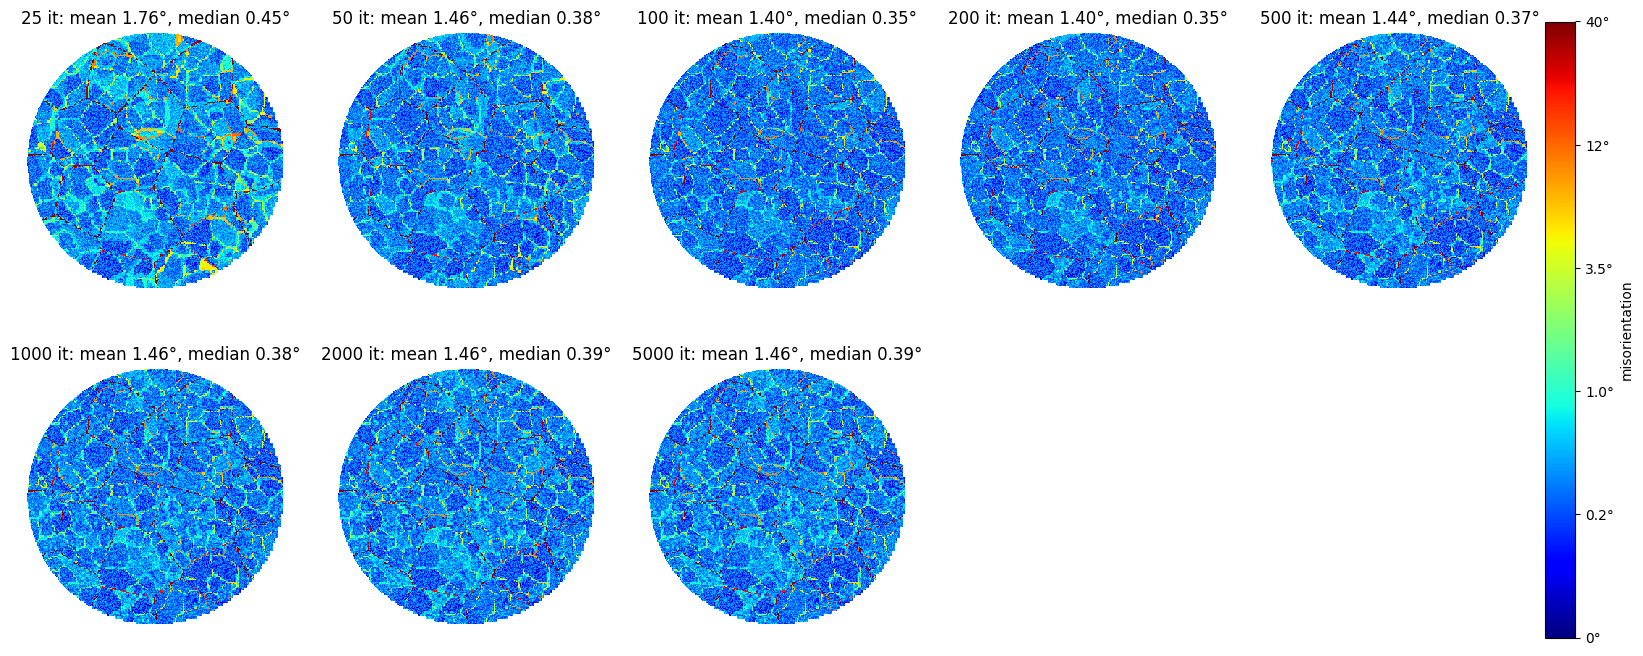

,mean (deg),median (deg),90th percentile (deg),fraction > 5 deg
map,,,,
25 it,1.756,0.446,1.450,0.053
50 it,1.459,0.384,0.862,0.041
100 it,1.396,0.349,0.725,0.039
200 it,1.395,0.346,0.724,0.039
500 it,1.445,0.367,0.827,0.040
1000 it,1.456,0.383,0.869,0.040
2000 it,1.463,0.388,0.874,0.040
5000 it,1.462,0.387,0.874,0.040


In [7]:
misori, misori_table = stability.misorientation_to_ground_truth(grid, maps)

fig, ax = panel_axes(len(maps))
for a, (label, m) in zip(ax, misori.items()):
    a.imshow(stability.misorientation_image(m, maps[label][1], MISORI_VMAX), interpolation="nearest")
    a.set_title(f"{label}: mean {np.nanmean(m):.2f}°, median {np.nanmedian(m):.2f}°")
stability.misorientation_colorbar(fig, list(ax), MISORI_VMAX)
fig.savefig(os.path.join(OUT, "misorientation.png"), dpi=100, bbox_inches="tight")
plt.show()

misori_table.round(3)

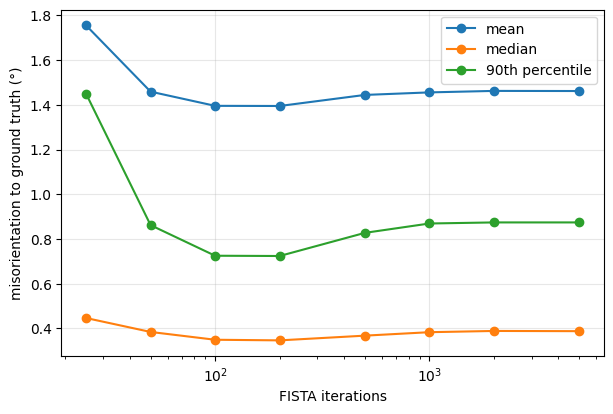

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for col in ["mean (deg)", "median (deg)", "90th percentile (deg)"]:
    ax.plot(values, misori_table[col].values, "o-", label=col.replace(" (deg)", ""))
ax.set_xlabel(PARAM_LABEL)
ax.set_ylabel("misorientation to ground truth (°)")
ax.set_xscale(PARAM_SCALE)
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(os.path.join(OUT, "misorientation_statistics.png"), dpi=100, bbox_inches="tight")
plt.show()

## 4. Grain and subgrain boundaries
Boundary pixels: kernel average misorientation (4 neighbours) of at least `GB_THRESHOLD` (grain) or
`SUBGRAIN_THRESHOLD` (subgrain), inside the sample eroded by one voxel; the ground truth is median
filtered first. Overlays: reconstruction dark red (grain) / light red (subgrain), ground truth dark
blue / light blue, mixed colours where both coincide.

Statistics, in micrometres: **deviation** = distance from each reconstructed boundary pixel to the
nearest ground-truth boundary of the same kind (spurious boundaries raise it); **gt → rec** = distance
from each ground-truth boundary pixel to the nearest reconstructed one (missing boundaries raise it).

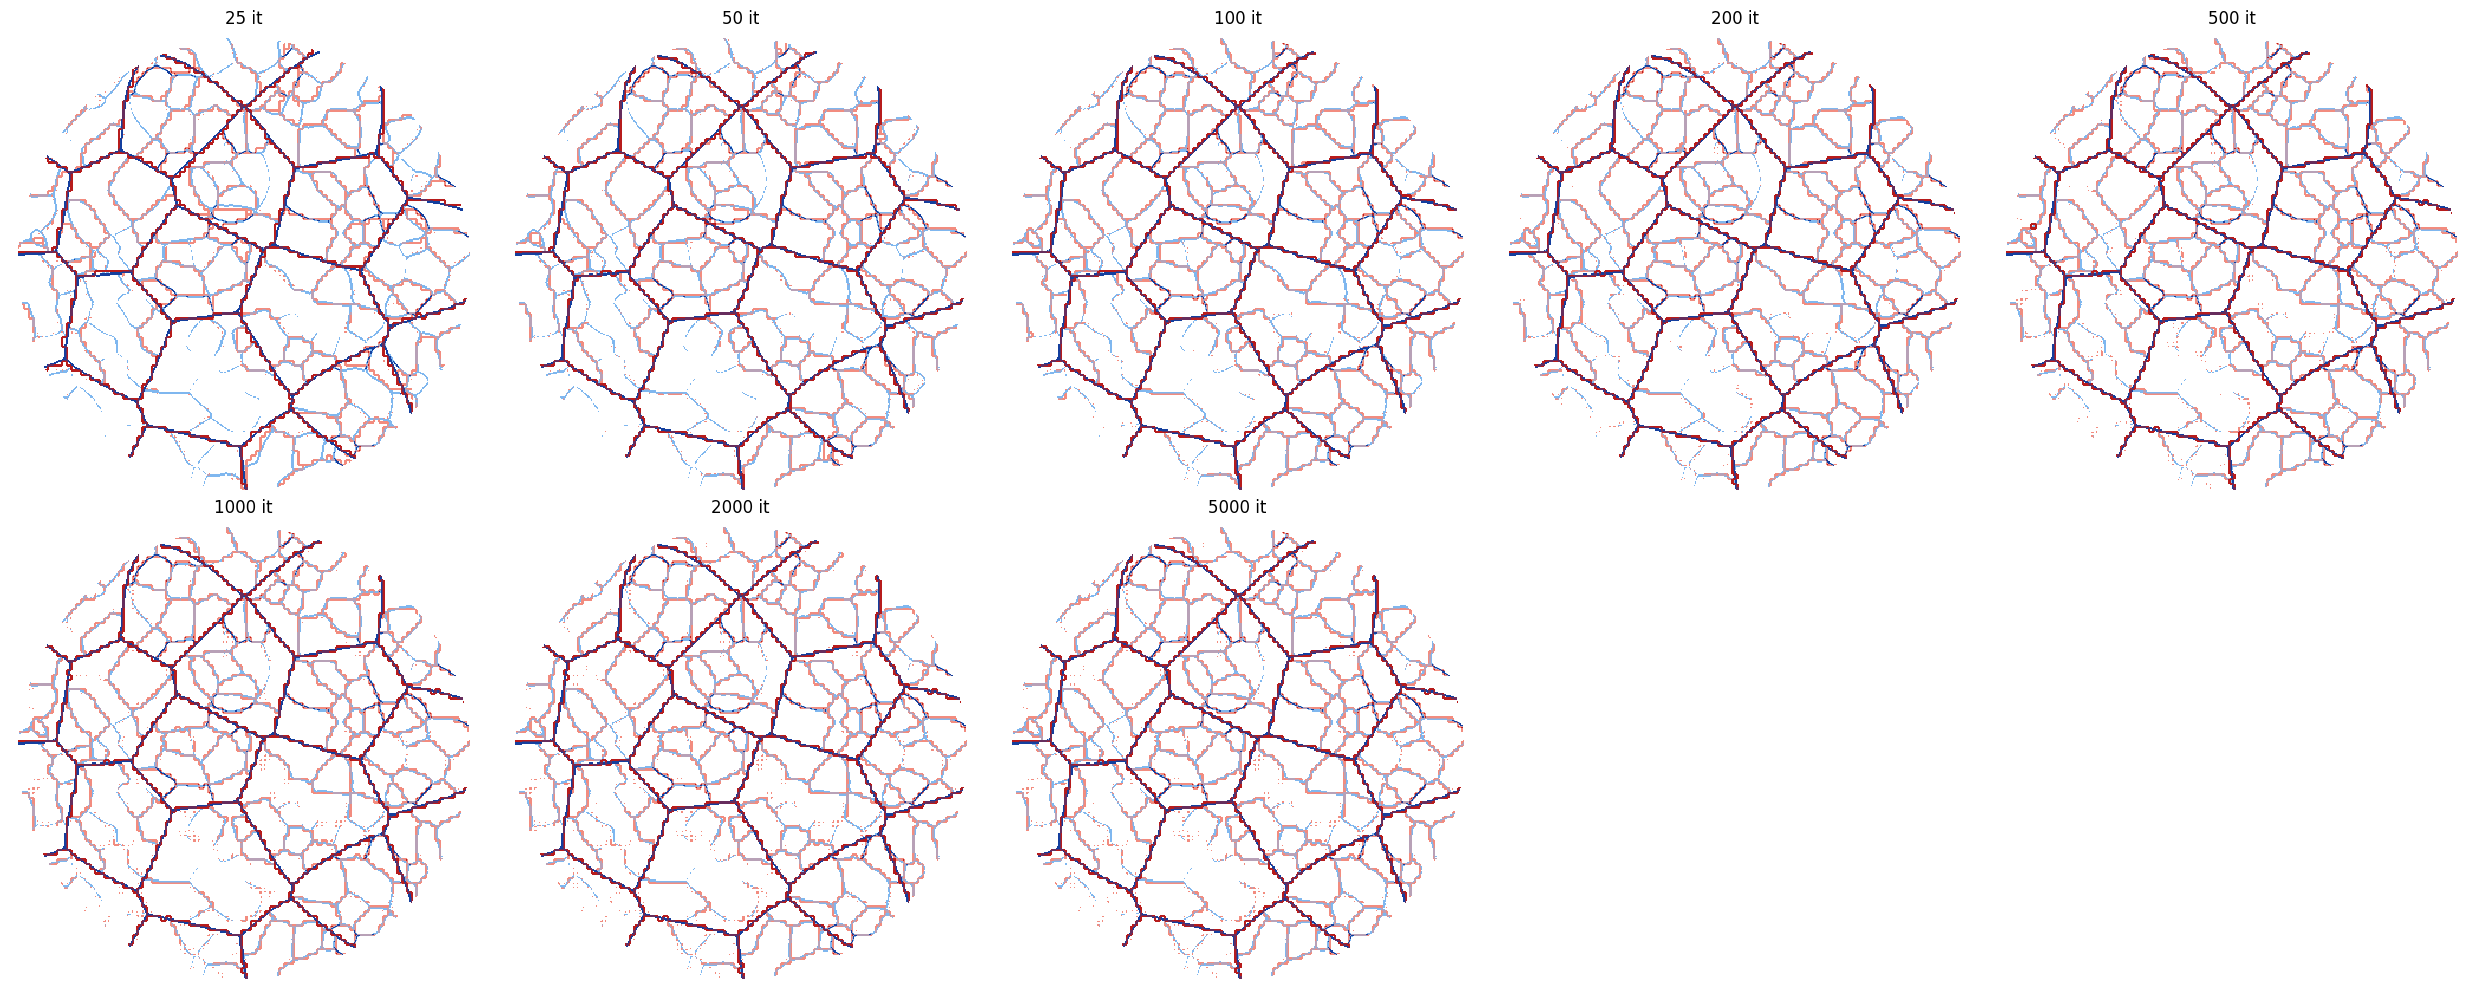

,map,boundary,pixels,pixels (gt),mean deviation (um),median deviation (um),mean gt -> rec (um),median gt -> rec (um)
0,25 it,grain,5691,4782,0.0205,0.0255,0.0238,0.0000
1,25 it,subgrain,15383,14420,0.0206,0.0255,0.0276,0.0255
2,50 it,grain,5699,4782,0.0168,0.0255,0.0183,0.0000
3,50 it,subgrain,16151,14420,0.0160,0.0000,0.0178,0.0000
4,100 it,grain,5729,4782,0.0164,0.0255,0.0154,0.0000
5,100 it,subgrain,16872,14420,0.0151,0.0000,0.0131,0.0000
6,200 it,grain,5802,4782,0.0165,0.0255,0.0146,0.0000
7,200 it,subgrain,17487,14420,0.0155,0.0000,0.0119,0.0000
8,500 it,grain,5876,4782,0.0183,0.0255,0.0150,0.0000
9,500 it,subgrain,18097,14420,0.0167,0.0255,0.0112,0.0000


In [9]:
gt_b, rec_b, boundary_table = stability.boundary_analysis(grid, maps, GB_THRESHOLD, SUBGRAIN_THRESHOLD)

fig, ax = panel_axes(len(maps), size=5)
for a, label in zip(ax, maps):
    a.imshow(stability.boundary_overlay(gt_b, rec_b[label]), interpolation="nearest")
    a.set_title(label)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "boundaries.png"), dpi=100, bbox_inches="tight")
plt.show()

boundary_table.round(4)

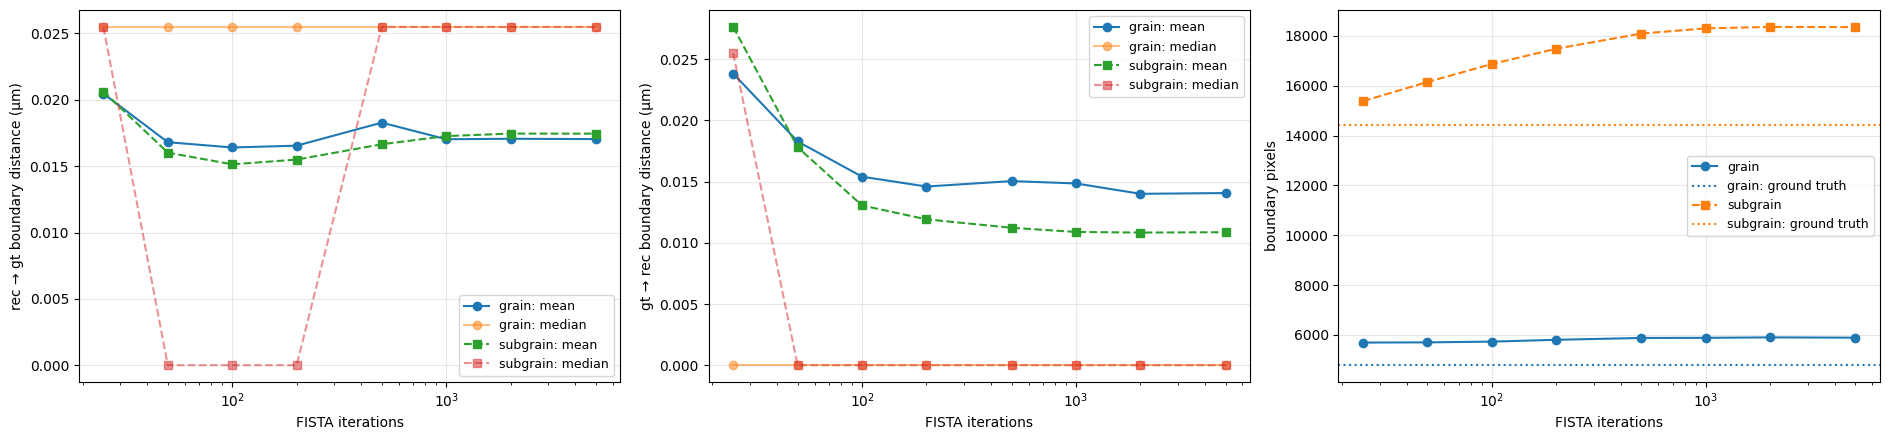

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(19, 4.5))
for kind, style in [("grain", "o-"), ("subgrain", "s--")]:
    t = boundary_table[boundary_table["boundary"] == kind]
    ax[0].plot(values, t["mean deviation (um)"].values, style, label=f"{kind}: mean")
    ax[0].plot(values, t["median deviation (um)"].values, style, alpha=0.5, label=f"{kind}: median")
    ax[1].plot(values, t["mean gt -> rec (um)"].values, style, label=f"{kind}: mean")
    ax[1].plot(values, t["median gt -> rec (um)"].values, style, alpha=0.5, label=f"{kind}: median")
    ax[2].plot(values, t["pixels"].values, style, label=kind)
    ax[2].axhline(t["pixels (gt)"].values[0], color=ax[2].lines[-1].get_color(), ls=":", label=f"{kind}: ground truth")
ax[0].set_ylabel("rec → gt boundary distance (µm)")
ax[1].set_ylabel("gt → rec boundary distance (µm)")
ax[2].set_ylabel("boundary pixels")
for a in ax:
    a.set_xlabel(PARAM_LABEL)
    a.set_xscale(PARAM_SCALE)
    a.legend(fontsize=9)
    a.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "boundary_statistics.png"), dpi=100, bbox_inches="tight")
plt.show()

## 5. Differences between the reconstructions
* mean / median misorientation between the medoid maps of every pair;
* the relative difference of the coefficients, ||x_row - x_col|| / ||x_col|| (all runs share the basis, so this is the change of the solution itself);
* misorientation maps between consecutive reconstructions in the sweep (same colour scale as above).

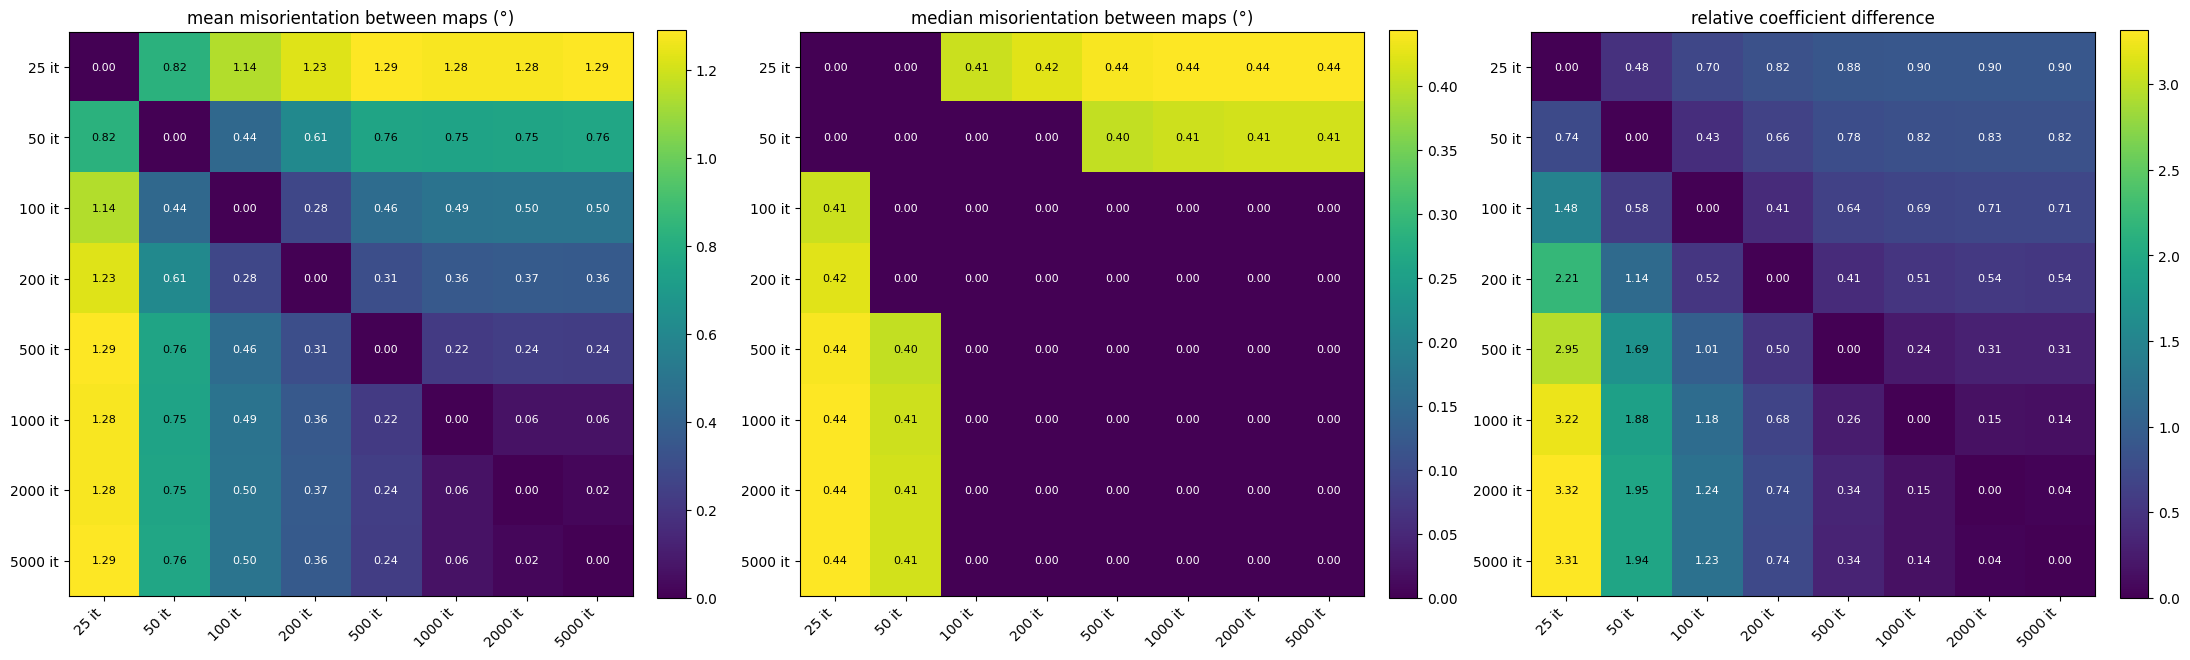

In [11]:
pair_mean, pair_median = stability.pairwise_misorientation(maps)
coeff_diff = stability.pairwise_coefficient_difference(files)

fig, ax = plt.subplots(1, 3, figsize=(22, 6.5))
heatmap(ax[0], pair_mean, "mean misorientation between maps (°)")
heatmap(ax[1], pair_median, "median misorientation between maps (°)")
heatmap(ax[2], coeff_diff, "relative coefficient difference")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "pairwise_differences.png"), dpi=100, bbox_inches="tight")
plt.show()

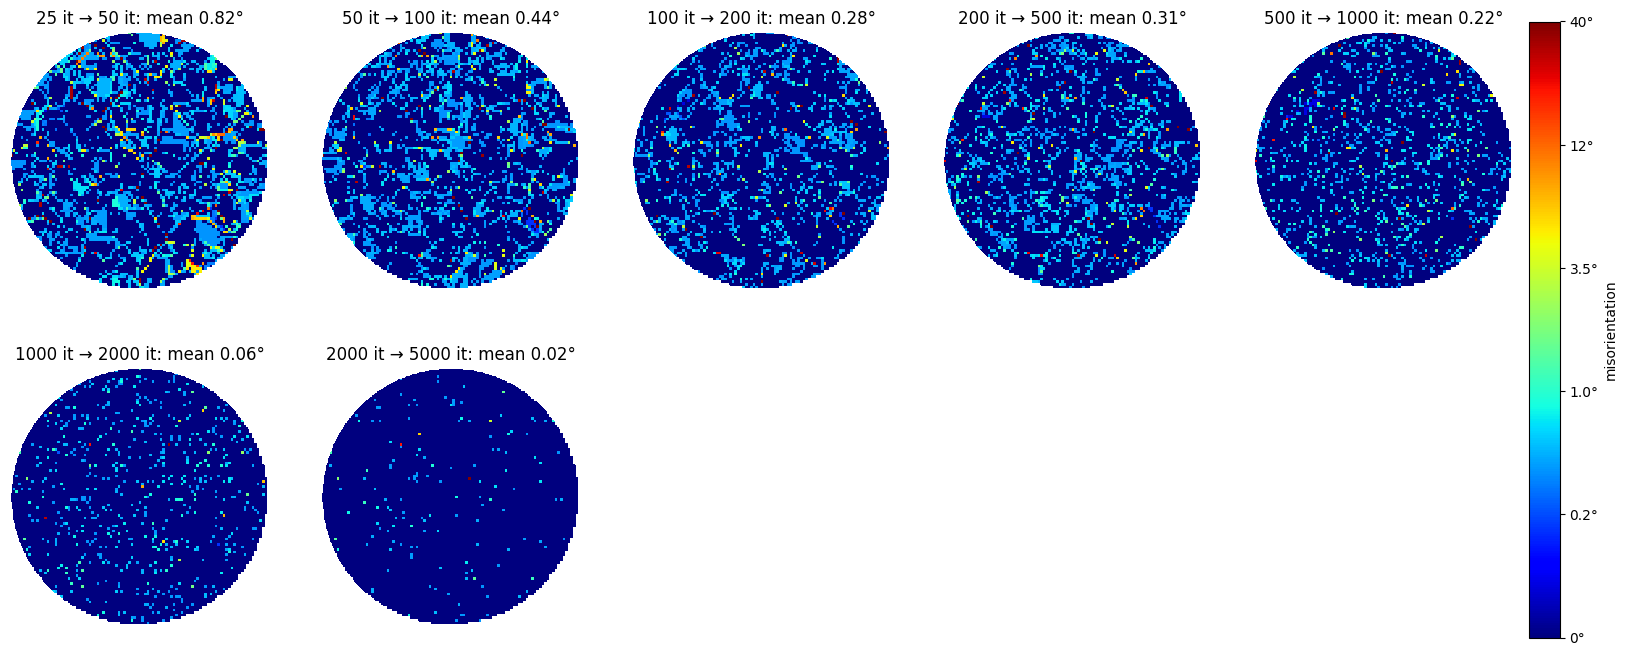

In [12]:
labels = list(maps)
fig, ax = panel_axes(len(labels) - 1)
for a, (prev, cur) in zip(ax, zip(labels[:-1], labels[1:])):
    both = maps[prev][1] & maps[cur][1]
    m = stability.figures.misorientation_map(maps[prev][0], maps[cur][0], both)
    a.imshow(stability.misorientation_image(m, both, MISORI_VMAX), interpolation="nearest")
    a.set_title(f"{prev} → {cur}: mean {np.nanmean(m):.2f}°")
stability.misorientation_colorbar(fig, list(ax), MISORI_VMAX)
fig.savefig(os.path.join(OUT, "consecutive_misorientation.png"), dpi=100, bbox_inches="tight")
plt.show()

## 6. Data versus prediction
The measured data next to the prediction A x of every reconstruction, as ring index versus eta: a
single detector frame (one rotation, one translation: `OMEGA_INDEX`, `TRANSLATION_INDEX`), and all
translations summed at that rotation; the panels of one figure share a colour scale (intensity ** `IMAGE_GAMMA`). The profiles below cut one
ring along eta (compare how the predicted peaks change with the number of iterations); grey: eta bins with zero weight in the fit (along the rotation axis).
The predictions are computed on the GPU once and cached in `OUT`.

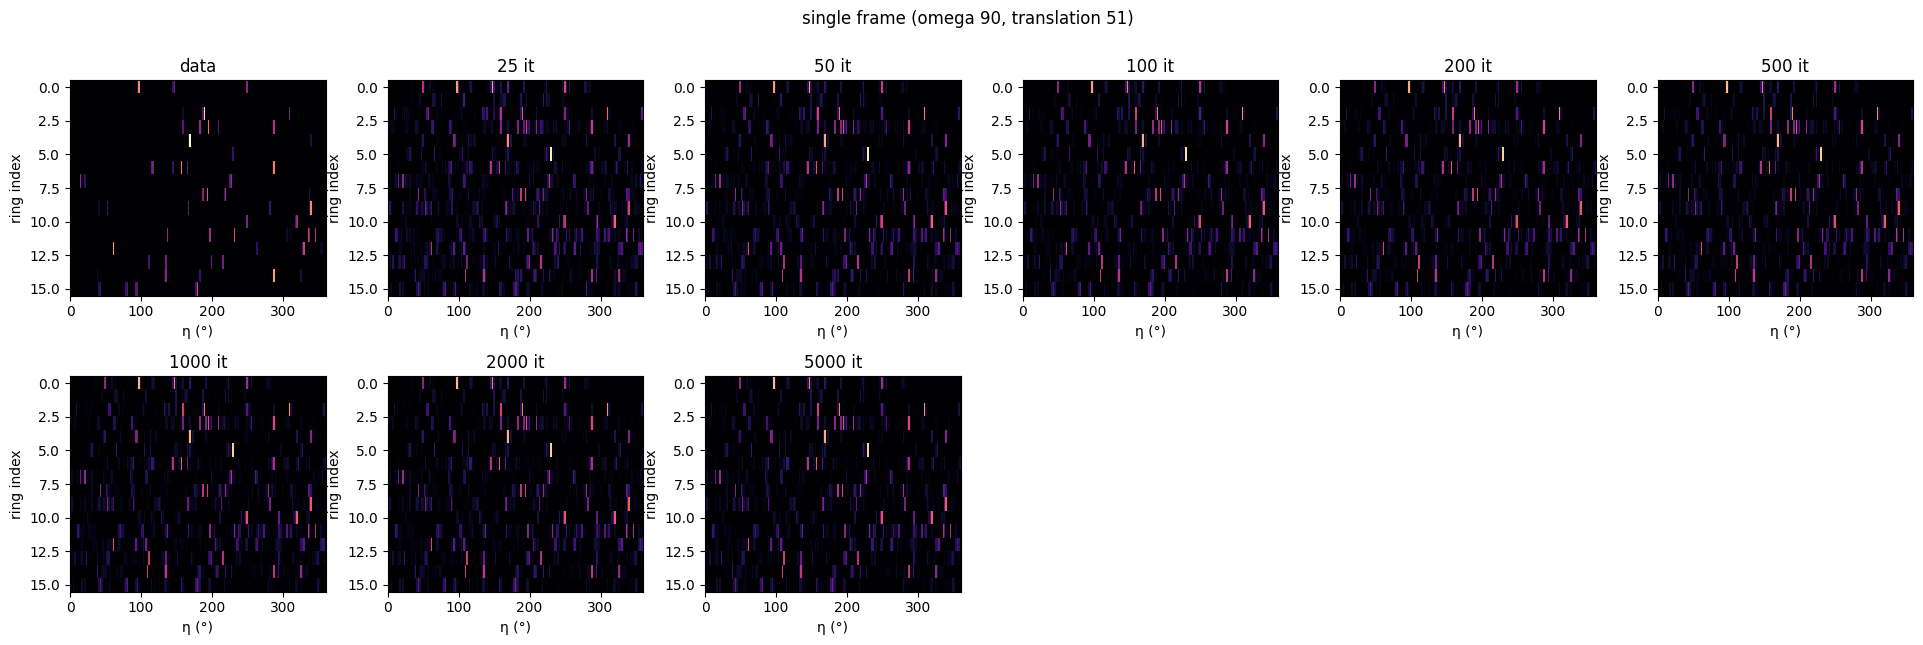

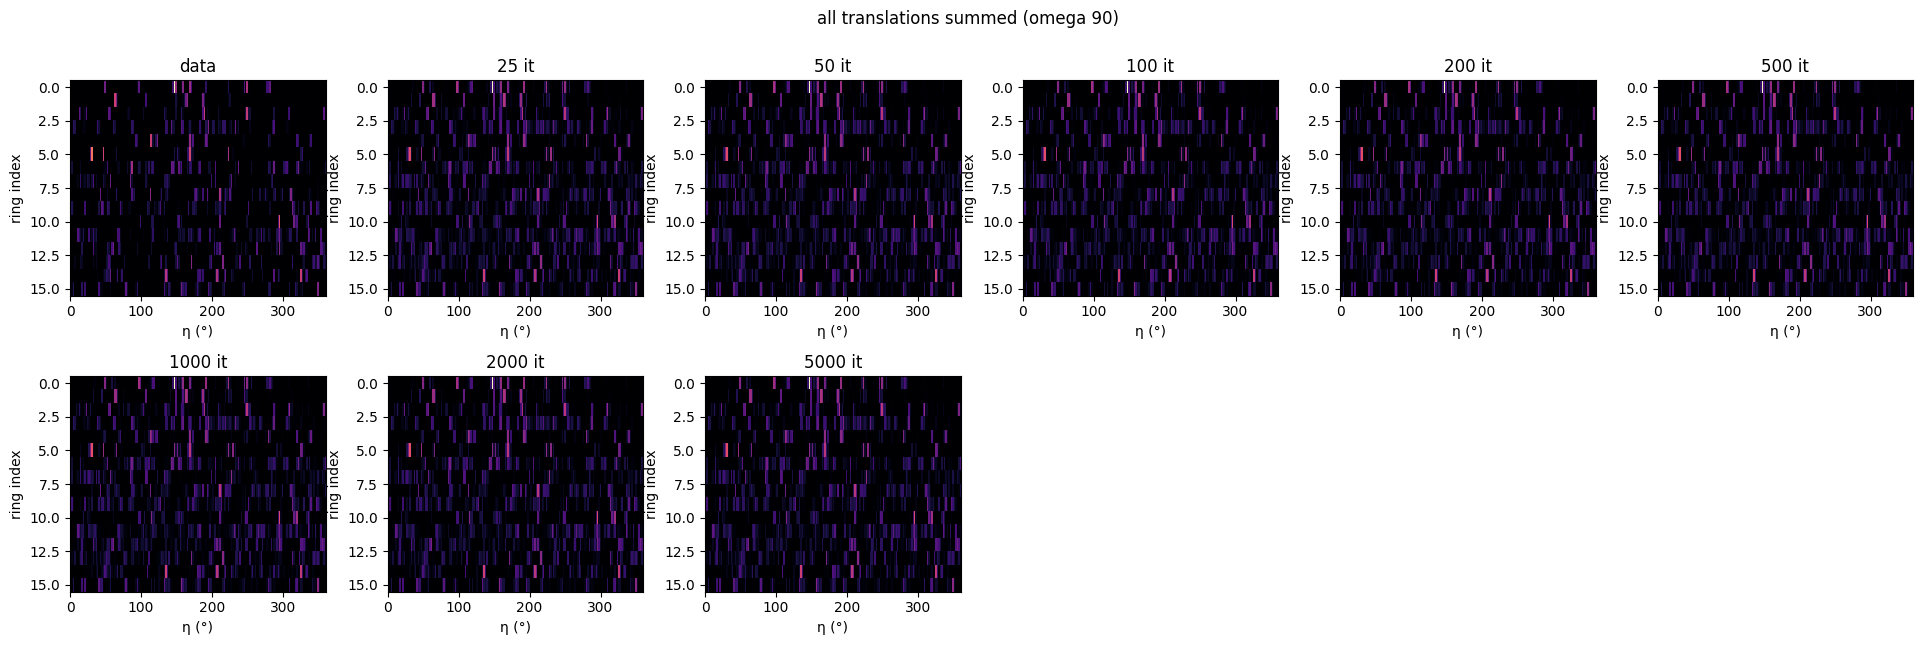

In [13]:
data_sl, pred_sl = stability.prediction_slices(files, SAMPLE, OMEGA_INDEX, TRANSLATION_INDEX, OUT)
n_eta, n_rings = data_sl["frame"].shape
eta = (np.arange(n_eta) + 0.5) * 360 / n_eta
masked = data_sl["eta_weight"] == 0

rows = [("frame", f"single frame (omega {OMEGA_INDEX}, translation {TRANSLATION_INDEX})"),
        ("summed", f"all translations summed (omega {OMEGA_INDEX})")]
for key, title in rows:
    panels = [("data", data_sl[key])] + [(label, p[key]) for label, p in pred_sl.items()]
    vmax = max(img.max() for _, img in panels)
    fig, ax = panel_axes(len(panels), ncols=6, size=3.2)
    for a, (label, img) in zip(ax, panels):
        a.axis("on")
        a.imshow(img.T, aspect="auto", extent=[0, 360, n_rings - 0.5, -0.5], interpolation="nearest",
                 cmap="magma", norm=PowerNorm(IMAGE_GAMMA, vmin=0, vmax=vmax))
        a.set_title(label)
        a.set_xlabel("η (°)")
        a.set_ylabel("ring index")
    fig.suptitle(title, y=1.0)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT, f"data_vs_prediction_{key}.png"), dpi=100, bbox_inches="tight")
    plt.show()

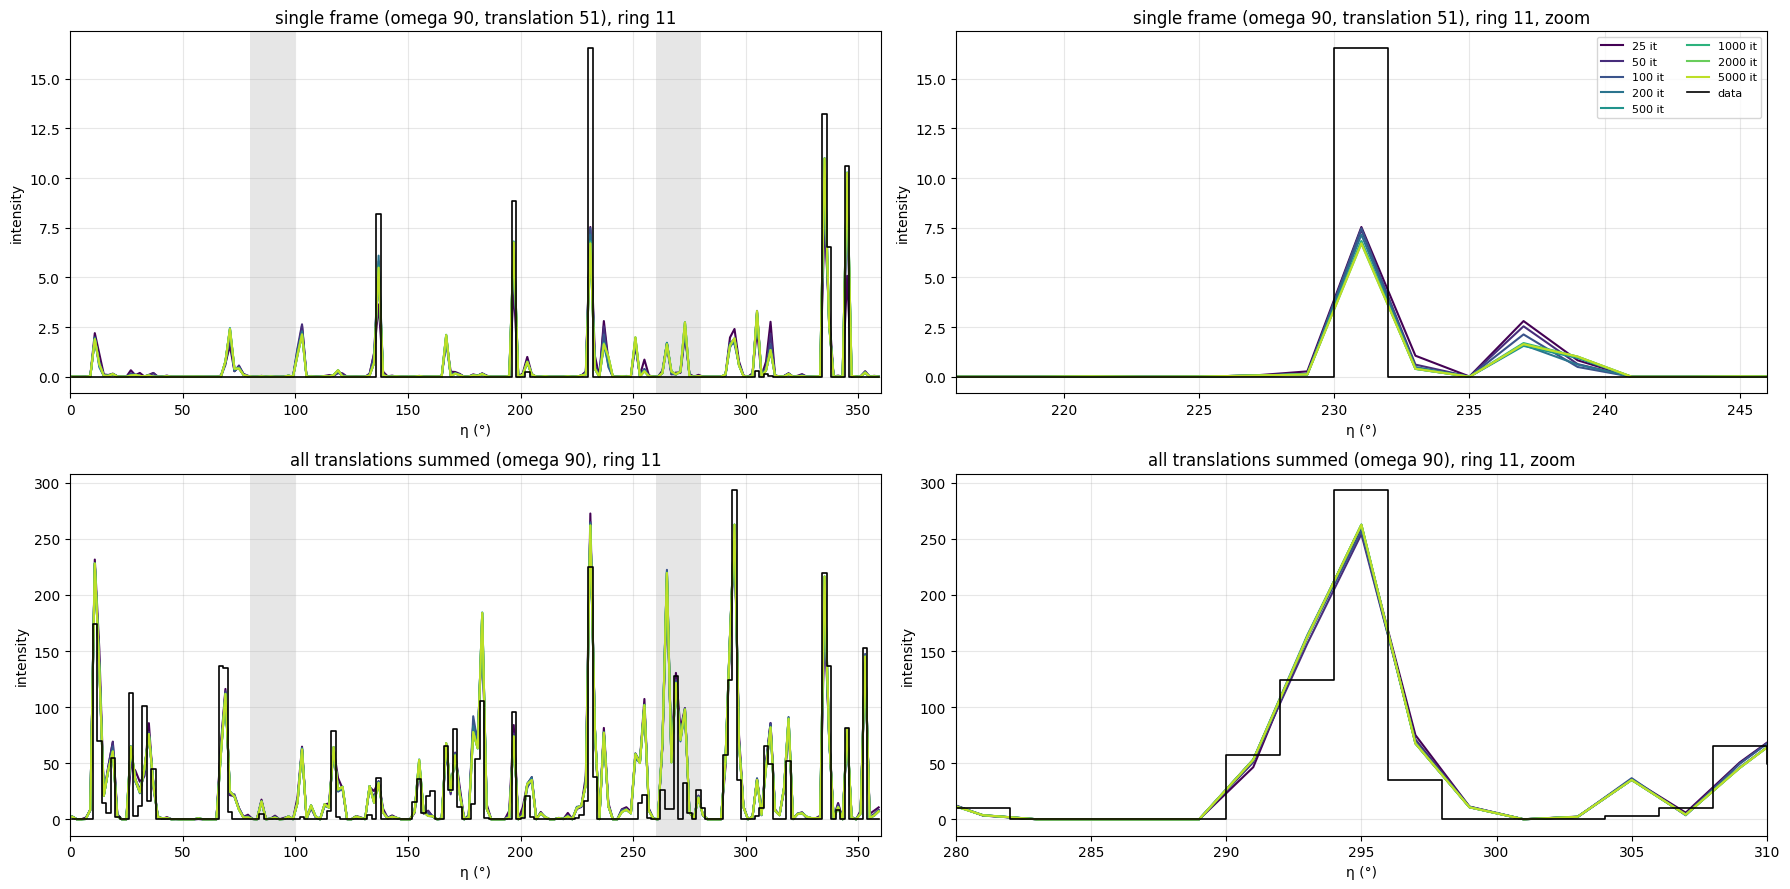

In [14]:
ring = RING if RING is not None else int(np.argmax(data_sl["frame"].sum(axis=0)))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(pred_sl)))
fig, ax = plt.subplots(2, 2, figsize=(18, 9))
for r, (key, title) in enumerate(rows):
    d = data_sl[key][:, ring]
    peak = eta[np.argmax(np.where(masked, -np.inf, d))]
    for c, xlim in enumerate([(0, 360), (peak - ZOOM_ETA, peak + ZOOM_ETA)]):
        a = ax[r, c]
        for i in np.where(masked)[0]:
            a.axvspan(i * 360 / n_eta, (i + 1) * 360 / n_eta, color="0.9", lw=0)
        for (label, p), col in zip(pred_sl.items(), colors):
            a.plot(eta, p[key][:, ring], color=col, lw=1.5, label=label)
        a.step(eta, d, where="mid", color="k", lw=1.2, label="data")
        a.set_xlim(xlim)
        a.set_xlabel("η (°)")
        a.set_ylabel("intensity")
        a.set_title(title.replace("\n", " ") + f", ring {ring}" + (", zoom" if c else ""))
        a.grid(alpha=0.3)
ax[0, 1].legend(fontsize=8, ncol=2)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "data_vs_prediction_profiles.png"), dpi=100, bbox_inches="tight")
plt.show()

## Tables

In [15]:
misori_table.to_csv(os.path.join(OUT, "misorientation_statistics.csv"))
boundary_table.to_csv(os.path.join(OUT, "boundary_statistics.csv"), index=False)
pair_mean.to_csv(os.path.join(OUT, "pairwise_mean_misorientation.csv"))
pair_median.to_csv(os.path.join(OUT, "pairwise_median_misorientation.csv"))
coeff_diff.to_csv(os.path.join(OUT, "pairwise_coefficient_difference.csv"))
runs.to_csv(os.path.join(OUT, "runs.csv"))
print("\n".join(sorted(f for f in os.listdir(OUT) if f.endswith((".png", ".csv")))))

boundaries.png
boundary_statistics.csv
boundary_statistics.png
consecutive_misorientation.png
convergence.png
data_vs_prediction_frame.png
data_vs_prediction_profiles.png
data_vs_prediction_summed.png
ipf_z.png
misorientation.png
misorientation_statistics.csv
misorientation_statistics.png
pairwise_coefficient_difference.csv
pairwise_differences.png
pairwise_mean_misorientation.csv
pairwise_median_misorientation.csv
runs.csv
